In [ ]:
pip install econml

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 86.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 57.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 151.9/151.9 kB 12.4 MB/s eta 0:00:00
  Attempting uninstall: shap
    Found existing installation: shap 0.51.0
    Uninstalling shap-0.51.0:
      Successfully uninstalled shap-0.51.0


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from econml.dml import CausalForestDML
from sklearn.ensemble import RandomForestRegressor

# -------------------------------
# 🔹 Load data
# -------------------------------
df = pd.read_csv("summer_2025.csv")

# -------------------------------
# 🔹 Convert datetime
# -------------------------------
df["datetime"] = pd.to_datetime(df["datetime"])

# -------------------------------
# 🔹 Filter Year = 2025
# -------------------------------
df = df[df["datetime"].dt.year == 2025]

# -------------------------------
# 🔹 Create Hour column
# -------------------------------
df["hour"] = df["datetime"].dt.hour

# -------------------------------
# 🔹 Filter SUMMER (Mar–May)
# -------------------------------
df_s = df[df["datetime"].dt.month.isin([3, 4, 5])].copy()

# -------------------------------
# 🔹 Clean data
# -------------------------------
df_s = df_s.dropna(subset=["wdLoad", "temp", "rh", "hour"])

print("Total Summer rows:", len(df_s))

Total Summer rows: 8832


Case 1: Temp → Load

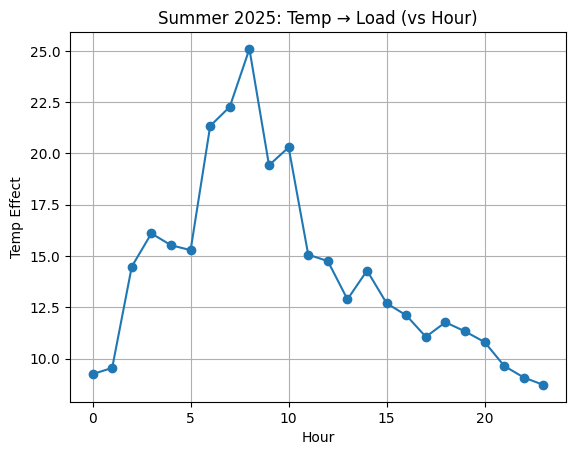

In [ ]:
Y = df_s["wdLoad"].values
T = df_s["temp"].values
X = df_s[["hour", "rh"]].values

model1 = CausalForestDML(
    model_y=RandomForestRegressor(),
    model_t=RandomForestRegressor(),
    random_state=42
)

model1.fit(Y, T, X=X)

effects1 = model1.effect(X)

df1 = pd.DataFrame(X, columns=["hour", "rh"])
df1["effect"] = effects1

hour_effect1 = df1.groupby("hour")["effect"].mean().reset_index()

plt.figure()
plt.plot(hour_effect1["hour"], hour_effect1["effect"], marker='o')
plt.xlabel("Hour")
plt.ylabel("Temp Effect")
plt.title("Summer 2025: Temp → Load (vs Hour)")
plt.grid()
plt.show()


In [ ]:
ate1 = model1.ate(X)
print("ATE (Temp → Load):", ate1)

ATE (Temp → Load): 14.28225709720654


CASE 2: RH → Load

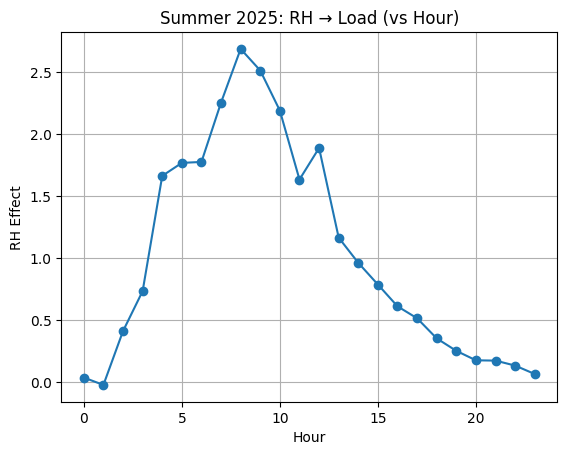

In [ ]:
T = df_s["rh"].values
X = df_s[["temp", "hour"]].values

model2 = CausalForestDML(
    model_y=RandomForestRegressor(),
    model_t=RandomForestRegressor(),
    random_state=42
)

model2.fit(Y, T, X=X)

effects2 = model2.effect(X)

df2 = pd.DataFrame(X, columns=["temp", "hour"])
df2["effect"] = effects2

hour_effect2 = df2.groupby("hour")["effect"].mean().reset_index()

plt.figure()
plt.plot(hour_effect2["hour"], hour_effect2["effect"], marker='o')
plt.xlabel("Hour")
plt.ylabel("RH Effect")
plt.title("Summer 2025: RH → Load (vs Hour)")
plt.grid()
plt.show()

In [ ]:
ate2 = model2.ate(X)
print("ATE (RH → Load):", ate2)

ATE (RH → Load): 1.0299141247334735


CASE 3: Hour → Load

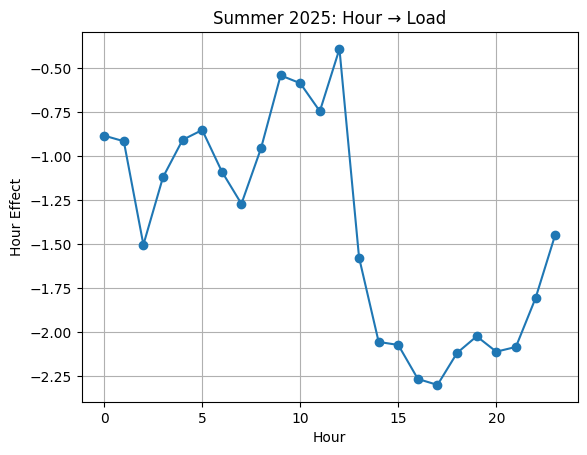

In [ ]:
T = df_s["hour"].values
X = df_s[["temp", "rh"]].values

model3 = CausalForestDML(
    model_y=RandomForestRegressor(),
    model_t=RandomForestRegressor(),
    random_state=42
)

model3.fit(Y, T, X=X)

effects3 = model3.effect(X)

df3 = pd.DataFrame(X, columns=["temp", "rh"])
df3["hour"] = T
df3["effect"] = effects3

hour_effect3 = df3.groupby("hour")["effect"].mean().reset_index()

plt.figure()
plt.plot(hour_effect3["hour"], hour_effect3["effect"], marker='o')
plt.xlabel("Hour")
plt.ylabel("Hour Effect")
plt.title("Summer 2025: Hour → Load")
plt.grid()
plt.show()

In [ ]:
ate3 = model3.ate(X)
print("ATE (Hour → Load):", ate3)

ATE (Hour → Load): -1.4011075373497093


CASE 4: Temp + RH → Load

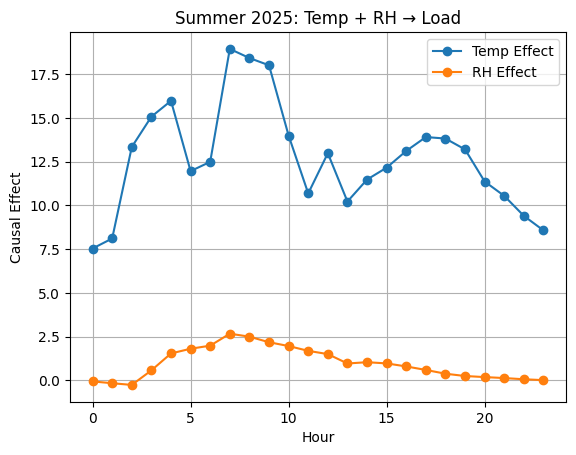

In [ ]:
T = df_s[["temp", "rh"]].values
X = df_s[["hour"]].values

model4 = CausalForestDML(
    model_y=RandomForestRegressor(),
    model_t=RandomForestRegressor(),
    random_state=42
)

model4.fit(Y, T, X=X)

effects4 = model4.const_marginal_effect(X)

df4 = pd.DataFrame(X, columns=["hour"])
df4["effect_temp"] = effects4[:, 0]
df4["effect_rh"] = effects4[:, 1]

hour_effect4 = df4.groupby("hour")[["effect_temp", "effect_rh"]].mean().reset_index()

plt.figure()
plt.plot(hour_effect4["hour"], hour_effect4["effect_temp"], marker='o', label="Temp Effect")
plt.plot(hour_effect4["hour"], hour_effect4["effect_rh"], marker='o', label="RH Effect")

plt.xlabel("Hour")
plt.ylabel("Causal Effect")
plt.title("Summer 2025: Temp + RH → Load")
plt.legend()
plt.grid()
plt.show()

In [ ]:
avg_effect = effects4.mean(axis=0)

print("ATE (Temp → Load):", avg_effect[0])
print("ATE (RH → Load):", avg_effect[1])

ATE (Temp → Load): 12.719652272743517
ATE (RH → Load): 0.9722021141995628
